In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(0,nmax):
        res += (n+1.0) * np.exp( -(n+1.0)*t )
        res += (n+1.0) * np.exp( -(n+1.0)*(T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(2*T-t) )
        res += (n+1.0) * np.exp( -(n+1.0)*(t+2*T) )
        res += (n+1.0) * np.exp( -(n+1.0)*(3*T-t) )
    return res/(4.0*np.pi)

In [4]:
masses_=[]

In [5]:
T=16
Nt=24 # 240

In [6]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

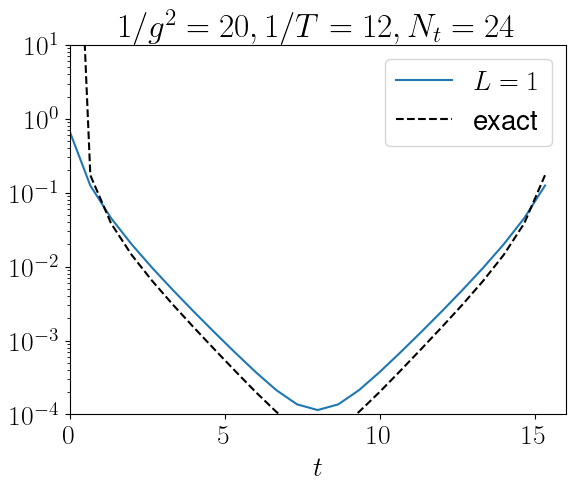

In [7]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [8]:
Nt/T

1.5

In [9]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [10]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [11]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

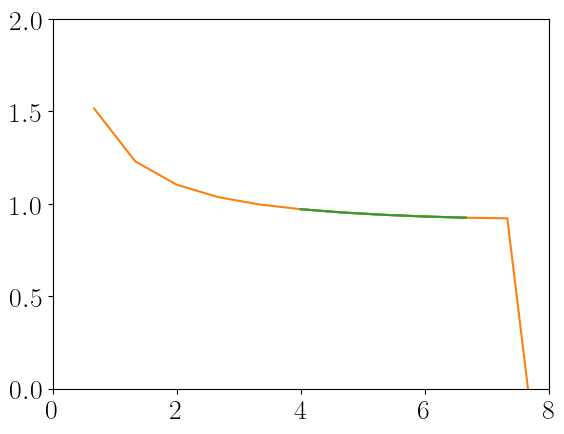

In [12]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [13]:
masses_.append([1, Nt, opt[0][0]])

In [14]:
Nt=48 # 240

In [15]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

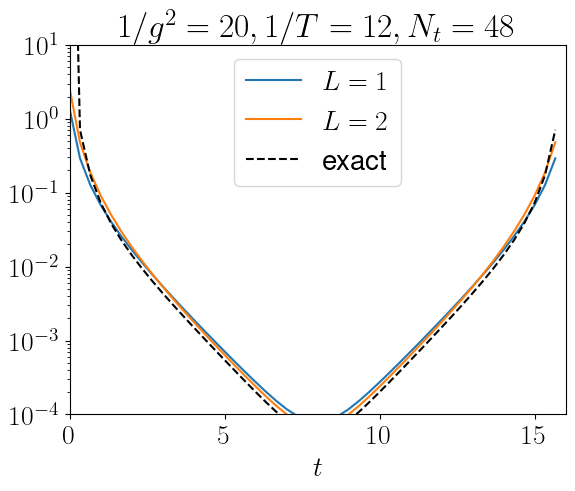

In [16]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [18]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [19]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [20]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

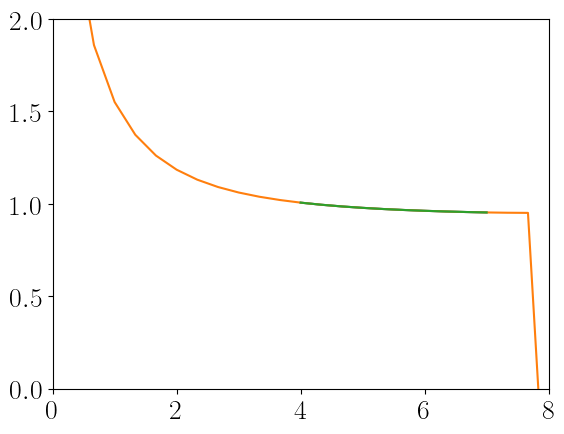

In [21]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [22]:
masses_.append([1, Nt, opt[0][0]])

In [23]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [24]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

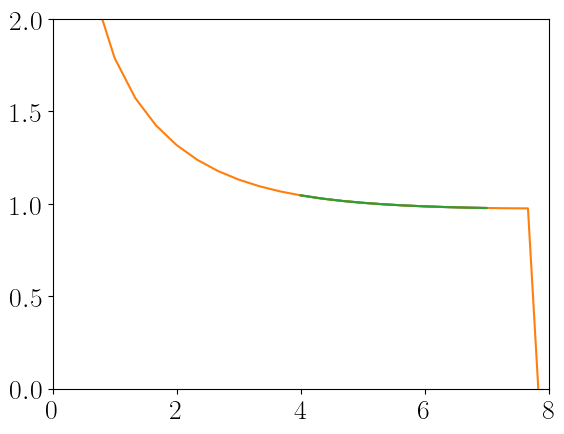

In [25]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [26]:
masses_.append([2, Nt, opt[0][0]])

In [27]:
Nt=64 # 240

In [28]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

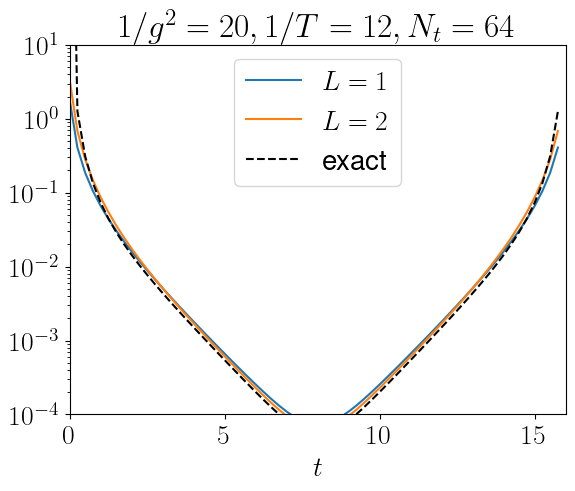

In [29]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [30]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [31]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [32]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

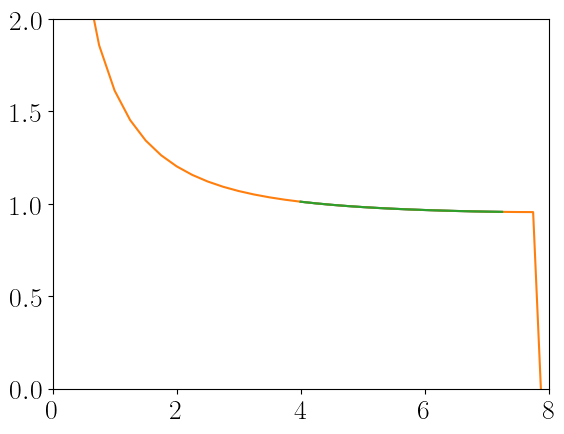

In [33]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [34]:
masses_.append([1, Nt, opt[0][0]])

In [35]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [36]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

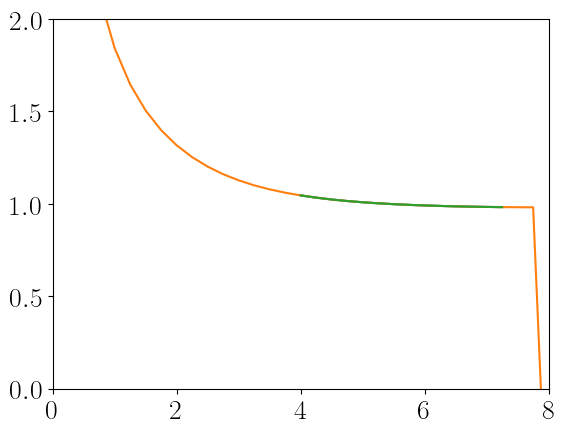

In [37]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [38]:
masses_.append([2, Nt, opt[0][0]])

In [39]:
Nt=96 # 240

In [40]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

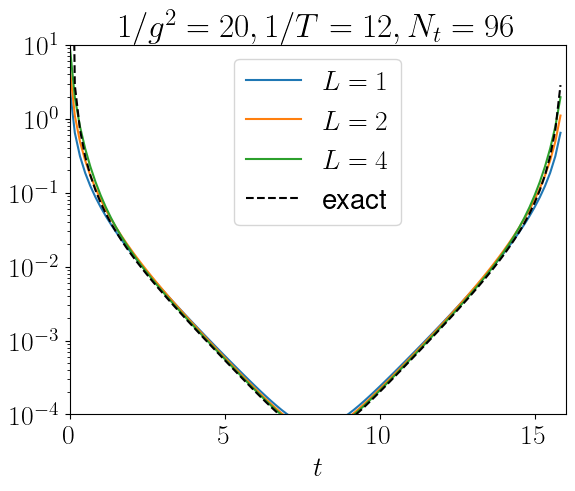

In [41]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [42]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [43]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [44]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

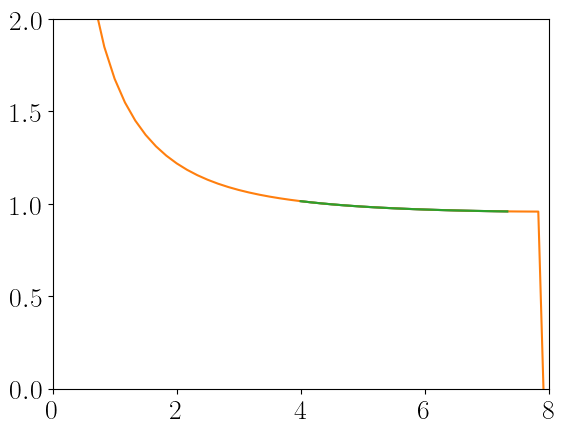

In [45]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [46]:
masses_.append([1, Nt, opt[0][0]])

In [47]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [48]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

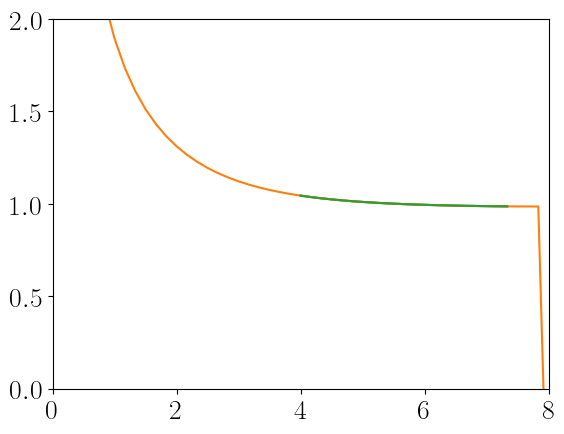

In [49]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [50]:
masses_.append([2, Nt, opt[0][0]])

In [51]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [52]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

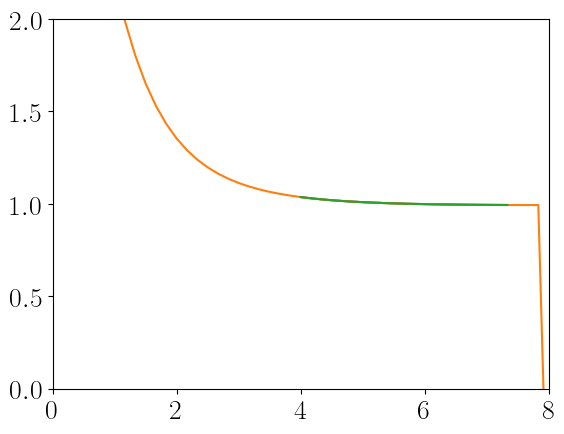

In [53]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [54]:
masses_.append([4, Nt, opt[0][0]])

In [55]:
T=16

In [56]:
Nt=120 # 240

In [57]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
# l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

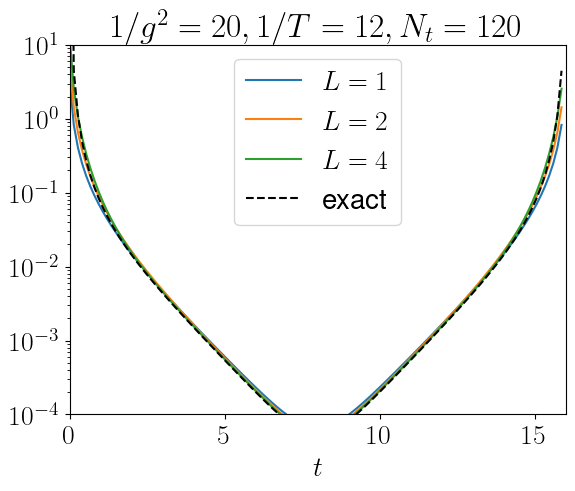

In [58]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [59]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [60]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [61]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

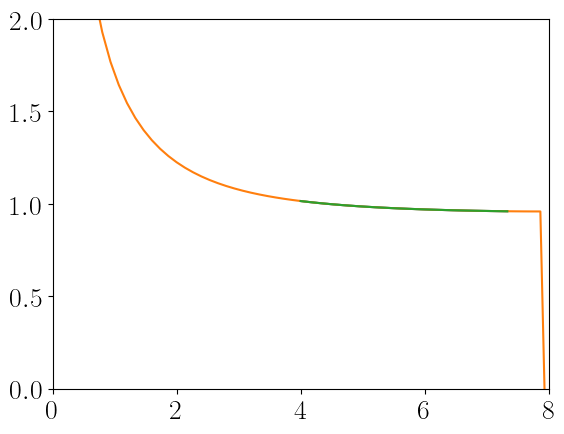

In [62]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [63]:
masses_.append([1, Nt, opt[0][0]])

In [64]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [65]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

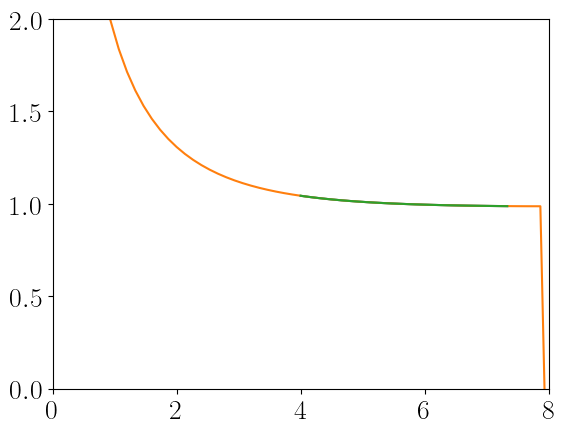

In [66]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [67]:
masses_.append([2, Nt, opt[0][0]])

In [68]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [69]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

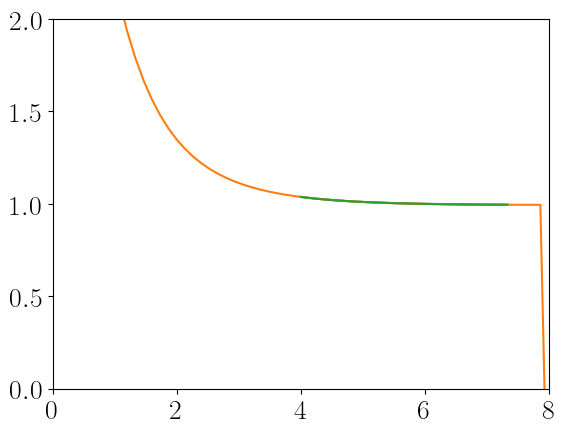

In [70]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [71]:
masses_.append([4, Nt, opt[0][0]])

In [72]:
Nt=144 # 240

In [73]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

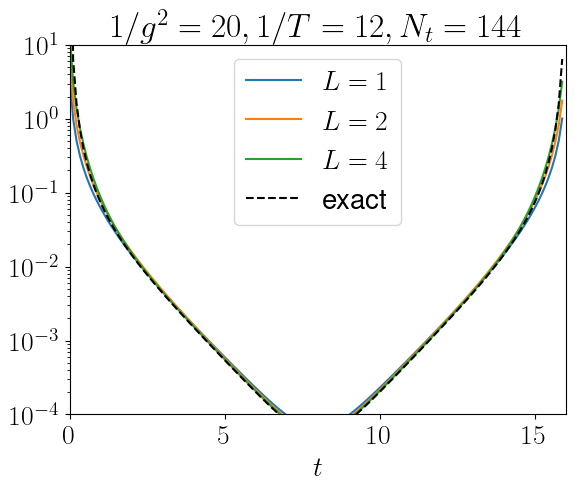

In [74]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [75]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [76]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [77]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

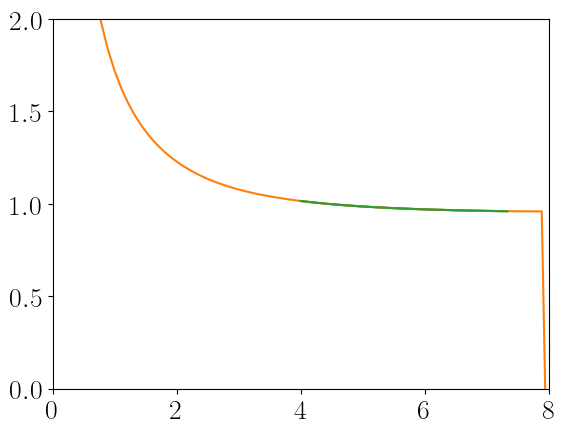

In [78]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [79]:
masses_.append([1, Nt, opt[0][0]])

In [80]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [81]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

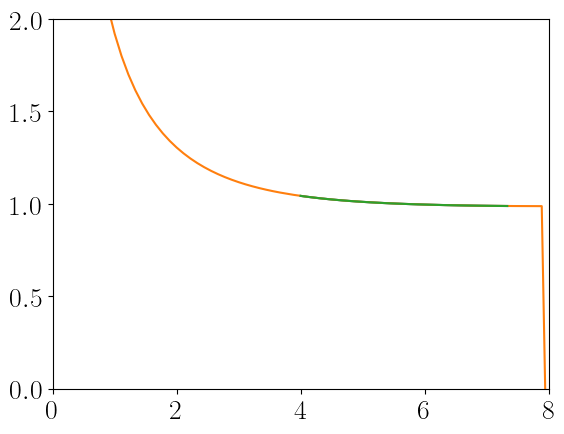

In [82]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [83]:
masses_.append([2, Nt, opt[0][0]])

In [84]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [85]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

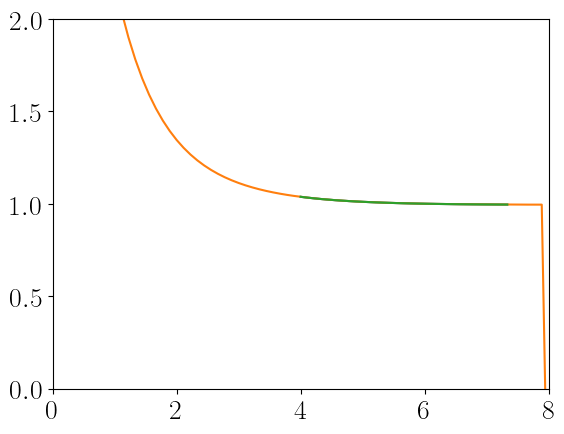

In [86]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [87]:
masses_.append([4, Nt, opt[0][0]])

In [88]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [89]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

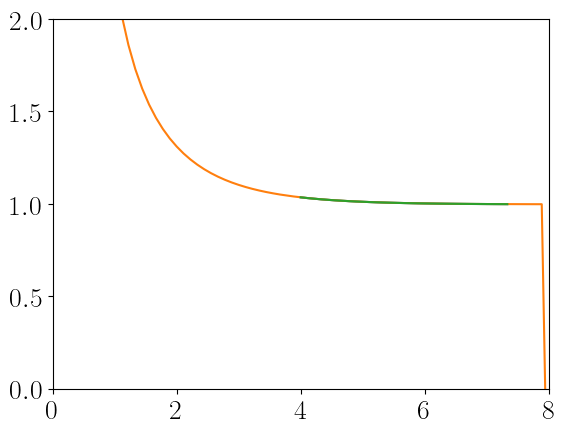

In [90]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [91]:
masses_.append([8, Nt, opt[0][0]])

In [92]:
Nt=160 # 240

In [93]:
l1_1 = np.loadtxt("ov_prop_temporal_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l2_1 = np.loadtxt("ov_prop_temporal_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l4_1 = np.loadtxt("ov_prop_temporal_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]
l8_1 = np.loadtxt("ov_prop_temporal_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat").T[1,::2]

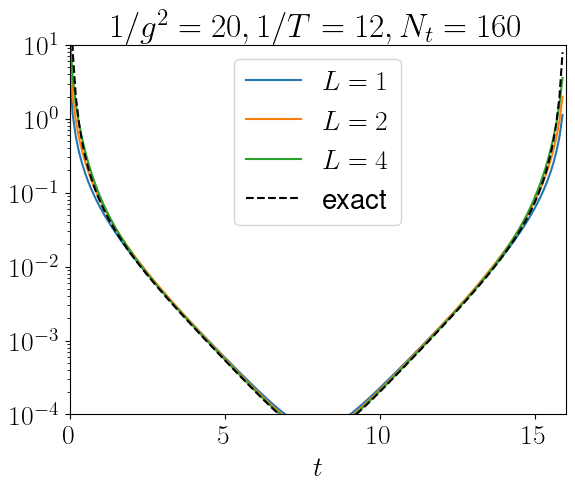

In [94]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
# plt.plot( xx, l8_1, label="$L=8$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-4, 1.0e1)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [95]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(7.5 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [96]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [97]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

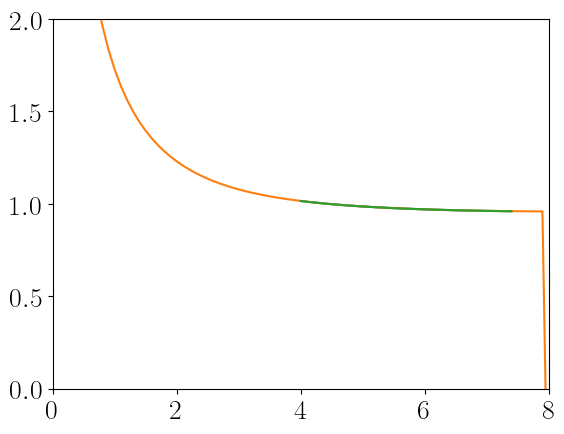

In [98]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [99]:
masses_.append([1, Nt, opt[0][0]])

In [100]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [101]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

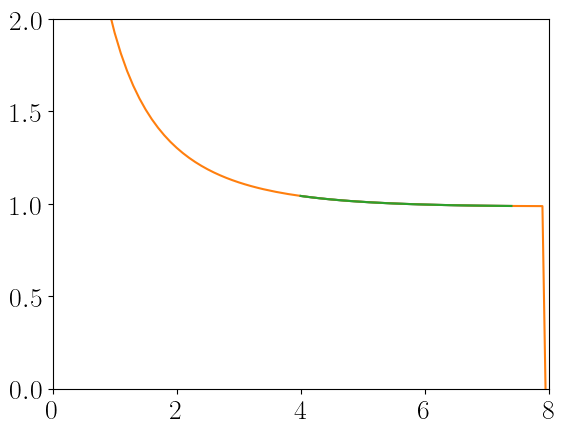

In [102]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [103]:
masses_.append([2, Nt, opt[0][0]])

In [104]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [105]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

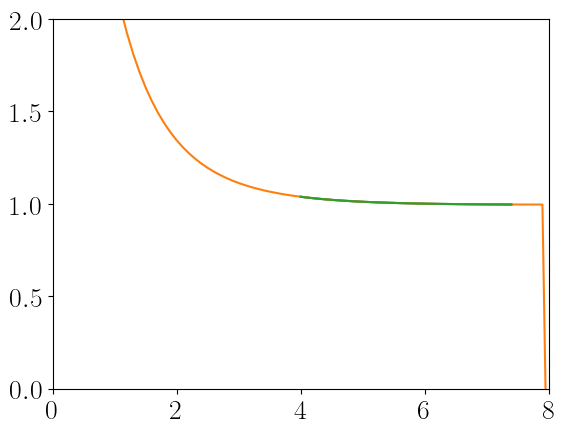

In [106]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [107]:
masses_.append([4, Nt, opt[0][0]])

In [108]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [109]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

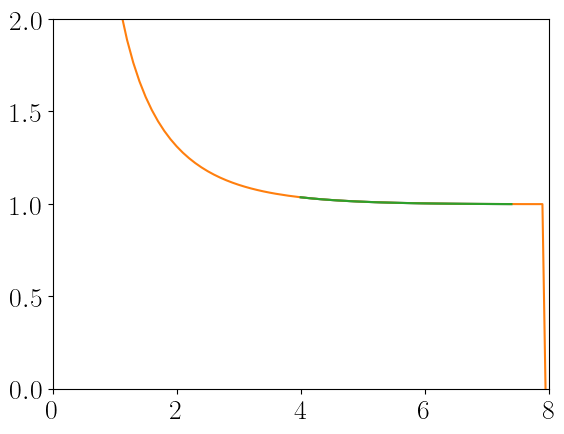

In [110]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [111]:
masses_.append([8, Nt, opt[0][0]])

In [115]:
masses = np.array(masses_)
masses

array([[  1.        ,  24.        ,   0.90827012],
       [  1.        ,  48.        ,   0.94177862],
       [  2.        ,  48.        ,   0.96927175],
       [  1.        ,  64.        ,   0.94736301],
       [  2.        ,  64.        ,   0.97652533],
       [  1.        ,  96.        ,   0.95112521],
       [  2.        ,  96.        ,   0.98174733],
       [  4.        ,  96.        ,   0.99197198],
       [  1.        , 120.        ,   0.95215356],
       [  2.        , 120.        ,   0.98326451],
       [  4.        , 120.        ,   0.99355352],
       [  1.        , 144.        ,   0.95269038],
       [  2.        , 144.        ,   0.98408619],
       [  4.        , 144.        ,   0.9944237 ],
       [  8.        , 144.        ,   0.99708414],
       [  1.        , 160.        ,   0.9529908 ],
       [  2.        , 160.        ,   0.9844967 ],
       [  4.        , 160.        ,   0.99480626],
       [  8.        , 160.        ,   0.99747478]])

In [116]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [117]:
masses

array([[  1.        ,  24.        ,   0.90827012],
       [  1.        ,  48.        ,   0.94177862],
       [  2.        ,  48.        ,   0.96927175],
       [  1.        ,  64.        ,   0.94736301],
       [  2.        ,  64.        ,   0.97652533],
       [  1.        ,  96.        ,   0.95112521],
       [  2.        ,  96.        ,   0.98174733],
       [  4.        ,  96.        ,   0.99197198],
       [  1.        , 120.        ,   0.95215356],
       [  2.        , 120.        ,   0.98326451],
       [  4.        , 120.        ,   0.99355352],
       [  1.        , 144.        ,   0.95269038],
       [  2.        , 144.        ,   0.98408619],
       [  4.        , 144.        ,   0.9944237 ],
       [  8.        , 144.        ,   0.99708414],
       [  1.        , 160.        ,   0.9529908 ],
       [  2.        , 160.        ,   0.9844967 ],
       [  4.        , 160.        ,   0.99480626],
       [  8.        , 160.        ,   0.99747478]])

In [118]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [119]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [120]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [121]:
opt1

(array([ 0.99796147, -0.03598761, -0.10559009]),
 array([[ 0.12418234, -0.1152537 , -0.08106   ],
        [-0.1152537 ,  0.23894008, -0.44958276],
        [-0.08106   , -0.44958276,  6.40783004]]),
 {'fvec': array([-1.35040111e-03,  3.37800572e-04,  4.38998294e-03, -1.13738625e-04,
          2.26925086e-03, -2.09620520e-04,  7.13573734e-04, -1.71112319e-04,
         -1.82066317e-04,  2.52299697e-04, -6.96752395e-04, -1.45313553e-04,
          4.19655639e-06, -9.93357576e-04, -1.23842923e-03, -1.98055051e-04,
         -1.58632589e-04, -1.12823650e-03, -1.38138858e-03]),
  'nfev': 9,
  'fjac': array([[-4.35889895,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573,  0.22941573,
           0.22941573,  0.22941573,  0.22941573,  0.22941573],
         [-2.54184172, -2.19583191, -0.16114202,  0.23805085, -0.16114202,
           0.23805085, -0.16114202, -0.2

In [122]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [123]:
masses2

array([[  2.        ,  48.        ,   0.96927175],
       [  2.        ,  64.        ,   0.97652533],
       [  2.        ,  96.        ,   0.98174733],
       [  4.        ,  96.        ,   0.99197198],
       [  2.        , 120.        ,   0.98326451],
       [  4.        , 120.        ,   0.99355352],
       [  2.        , 144.        ,   0.98408619],
       [  4.        , 144.        ,   0.9944237 ],
       [  8.        , 144.        ,   0.99708414],
       [  2.        , 160.        ,   0.9844967 ],
       [  4.        , 160.        ,   0.99480626],
       [  8.        , 160.        ,   0.99747478]])

In [124]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [125]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [126]:
opt2

(array([ 0.99982589, -0.03972501, -0.15048406]),
 array([[  0.27092429,  -0.7519157 ,  -1.12104273],
        [ -0.7519157 ,   5.08192178, -11.08534335],
        [ -1.12104273, -11.08534335, 124.05626519]]),
 {'fvec': array([-3.89822565e-05,  2.26313706e-05,  2.57726023e-05,  1.11064665e-04,
          1.34382539e-05,  3.43642770e-05,  9.20358525e-06, -1.83724318e-05,
         -1.26021576e-05, -4.83187195e-05, -4.79445141e-05, -5.02546743e-05]),
  'nfev': 9,
  'fjac': array([[-3.46410162,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513,  0.28867513,  0.28867513,  0.28867513,
           0.28867513,  0.28867513],
         [-0.72145207, -0.49438572,  0.22123976, -0.30371999,  0.22123976,
          -0.30371999,  0.22123976, -0.30371999, -0.43947782,  0.22123976,
          -0.30371999, -0.43947782],
         [-0.09577066, -0.04417701,  0.08978228,  0.03966051,  0.43990505,
           0.1510409 ,  0.50040777,  0.21154363,  0.13684158,  0.52653454,
       

In [127]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.1       ],
       [0.59094644, 0.1       ],
       [0.29947447, 0.1       ],
       [0.15022749, 0.1       ]])

In [130]:
opt3= sp.optimize.curve_fit( fitter, a_s[5:].T, masses[5:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [131]:
opt3

(array([ 0.99927275, -0.03643139, -0.14916423]),
 array([[ 5.25681022e-01, -1.04260875e-01, -2.50413527e+01],
        [-1.04260875e-01,  3.05251657e-01, -2.59550334e+00],
        [-2.50413527e+01, -2.59550334e+00,  1.62786872e+03]]),
 {'fvec': array([-6.52715640e-04,  6.59479609e-04, -1.10030726e-04, -1.89420011e-04,
          6.33946998e-04, -1.99929376e-04,  8.40317977e-05,  6.22542903e-04,
         -2.59835512e-04, -4.75122058e-04,  1.33501251e-04,  5.61924709e-04,
         -2.92503483e-04, -5.15870463e-04]),
  'nfev': 9,
  'fjac': array([[-3.74165739e+00,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01,  2.67261242e-01,
           2.67261242e-01,  2.67261242e-01],
         [-1.79168194e+00,  1.82236348e+00,  2.99988166e-01,
          -3.23429293e-01,  1.57572710e-01,  2.99988166e-01,
          -3.23429293e-01,  1.57572710e-01,  2.999

In [132]:
opt4= sp.optimize.curve_fit( fitter, a_s2[5:].T, masses2[5:].T[2],
                       p0=(1.0, 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [133]:
opt4

(array([ 0.99998854, -0.03977016, -0.16178934]),
 array([[ 3.84451651e+00, -2.01411043e+00, -2.81461689e+02],
        [-2.01411043e+00,  8.35570705e+00,  6.64691354e+01],
        [-2.81461689e+02,  6.64691354e+01,  2.24362600e+04]]),
 {'fvec': array([-8.02450013e-06,  1.65063754e-05,  6.50196394e-07,  9.45128813e-06,
         -1.44973680e-05, -2.40332453e-06, -1.68266720e-06]),
  'nfev': 9,
  'fjac': array([[-2.64575131e+00,  3.77964473e-01,  3.77964473e-01,
           3.77964473e-01,  3.77964473e-01,  3.77964473e-01,
           3.77964473e-01],
         [-3.82737144e-01, -3.50096040e-01, -1.13958935e-01,
          -3.05667993e-01,  6.27359896e-01, -1.13958935e-01,
          -3.05667993e-01],
         [-3.20569214e-02,  1.03718628e-03,  6.67612974e-03,
           2.64680853e-01,  4.13287729e-01,  5.74372979e-01,
           6.16030496e-01]]),
  'ipvt': array([1, 2, 3], dtype=int32),
  'qtf': array([ 6.83978200e-10,  6.55966317e-11, -1.89945219e-09])},
 'Both actual and predicted relativ

In [134]:
[3,4,5]

[3, 4, 5]

In [135]:
slices=[1]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]

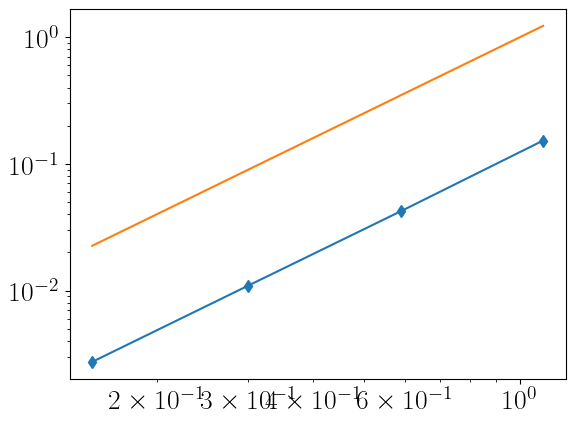

In [136]:
slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )*(1-.002)
plt.plot( xxx, yyy-lim, label="$L_t=144$", marker='d' )

plt.plot( xxx, xxx**2 )

plt.xscale("log")
plt.yscale("log")

In [156]:
a_s

array([[1.10714872, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111],
       [1.10714872, 0.1       ],
       [0.59094644, 0.1       ],
       [0.29947447, 0.1       ],
       [0.15022749, 0.1       ]])

In [157]:
a_s[slices]

array([[1.10714872, 0.11111111],
       [0.59094644, 0.11111111],
       [0.29947447, 0.11111111],
       [0.15022749, 0.11111111]])

In [ ]:
a_s[16:][0][1]

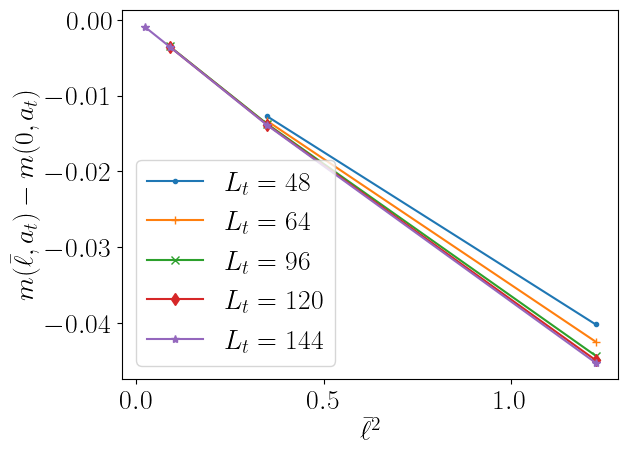

In [172]:
slices=[1,2]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=48$", marker='.' )

slices=[3,4]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=64$", marker='+' )

slices=[5,6,7]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=96$", marker='x' )

slices=[8,9,10]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=120$", marker='d' )

slices=[11,12,13,14]
xxx=a_s[slices].T[0]
yyy=masses.T[2][slices]
lim = fitter( [0.0, a_s[slices][0,1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L_t=144$", marker='*' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

plt.savefig("ellbar_scaling_fermion.pdf", bbox_inches="tight")

In [173]:
a_s[14:]

array([[0.15022749, 0.11111111],
       [1.10714872, 0.1       ],
       [0.59094644, 0.1       ],
       [0.29947447, 0.1       ],
       [0.15022749, 0.1       ]])

[0.94177862 0.94736301 0.95112521 0.95215356 0.95269038 0.9529908 ]
[0.96927175 0.97652533 0.98174733 0.98326451 0.98408619 0.9844967 ]
[0.99197198 0.99355352 0.9944237  0.99480626]
[0.99708414 0.99747478]


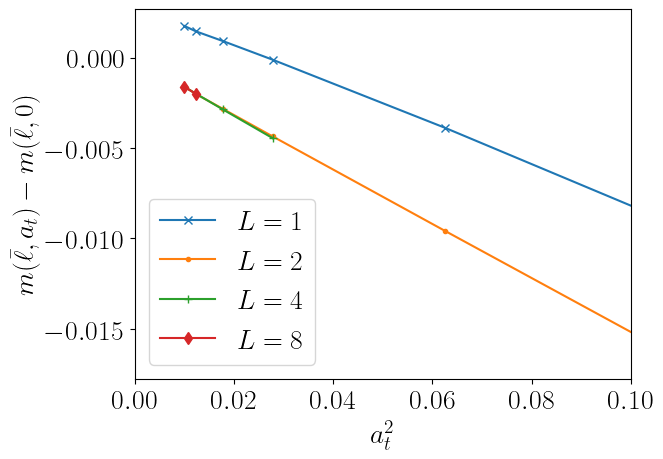

In [175]:
slices=[1,3,5,8,11,15]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=1$", marker='x' )

slices=[2,4,6,9,12,16]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=2$", marker='.' )

slices=[7,10,13,17]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=4$", marker='+' )

slices=[14,18]
xxx=a_s[slices].T[1]
yyy=masses.T[2][slices]
print(yyy)
lim = fitter( [a_s[slices][0,0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( xxx**2, yyy-lim, label="$L=8$", marker='d' )

plt.xlim(0,0.1)
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_fermion.pdf", bbox_inches="tight")

In [166]:
print(masses.T[2][slices])

[0.99708414]


In [164]:
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

NameError: name 'ibase' is not defined

In [ ]:
# slices=[1,2]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=48$", marker='d' )

# slices=[3,4]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=64$", marker='d' )

# slices=[5,6,7]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=96$", marker='d' )

# slices=[8,9,10]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=120$", marker='d' )

# slices=[11,12,13,14]
# xxx=a_s[slices].T[0]
# yyy=masses.T[2][slices]
# lim = fitter( [0.0, xxx], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( xxx**2, lim-yyy, label="$L_t=144$", marker='d' )

# plt.legend()

# plt.xlabel("$\\bar{\\ell}^2$")
# plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

# plt.savefig("ellbar_scaling_fermion.pdf", bbox_inches="tight")

In [ ]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

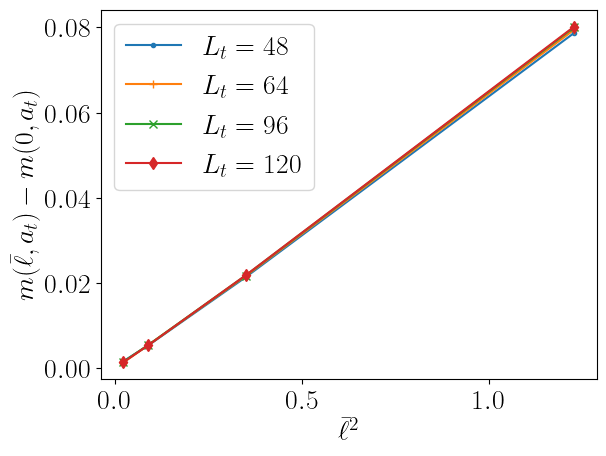

In [241]:
# lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[:4].T[0]**2, lim-masses.T[2][:4], label="$L_t=24$", marker='x' )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, lim-masses.T[2][4:8], label="$L_t=48$", marker='.' )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, lim-masses.T[2][8:12], label="$L_t=64$", marker='+' )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, lim-masses.T[2][12:16], label="$L_t=96$", marker='x' )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, lim-masses.T[2][16:], label="$L_t=120$", marker='d' )

plt.legend()

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

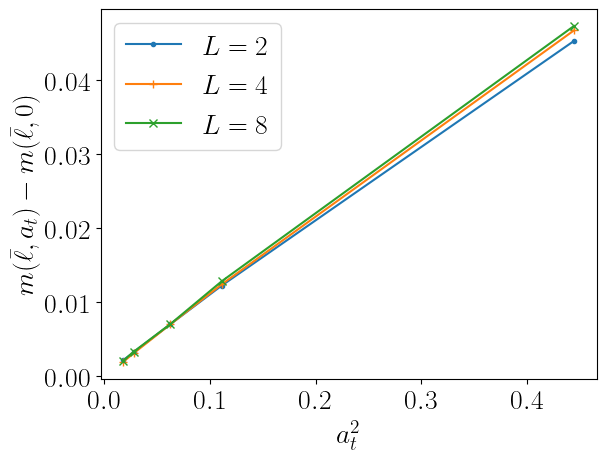

In [242]:
# ibase=0
# lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
# plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='d' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='x' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$m(\\bar\\ell, a_t) - m(\\bar\\ell, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [244]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [ ]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

In [118]:
opt1[0][0]

1.4068732750000403

In [119]:
masses.T[2][::4]

array([1.2930765 , 1.32292346, 1.32765725, 1.33102841, 1.33197963])

In [120]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749, 0.29947447])

In [121]:
a_s[4:8]

array([[1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333]])

In [122]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [123]:
ibase=1

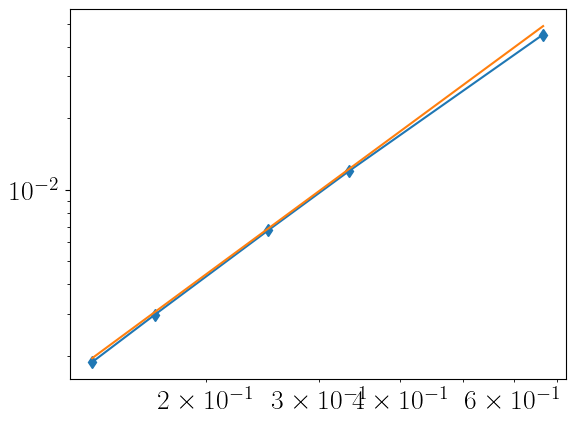

In [124]:
plt.plot( a_s[ibase::4].T[1], 1.3922-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [125]:
ibase=2

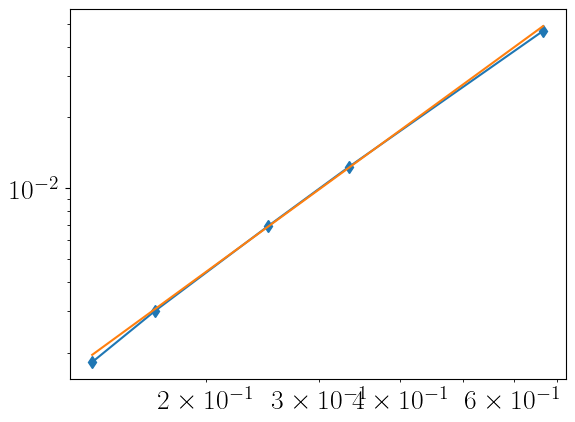

In [126]:
plt.plot( a_s[ibase::4].T[1], 1.4085-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [127]:
ibase=3

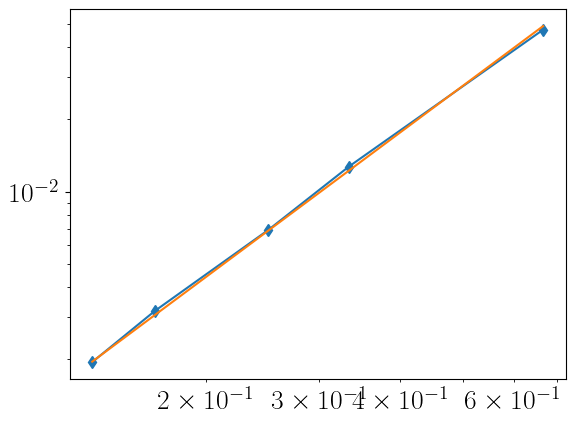

In [128]:
plt.plot( a_s[ibase::4].T[1], 1.41265-masses.T[2][ibase::4], label="$L_t=240$", marker='d' )

plt.plot( a_s[ibase::4].T[1], 0.11*a_s[ibase::4].T[1]**2, label="quad" )

plt.xscale("log")
plt.yscale("log")

In [129]:
a_s[3::4].T[1]

array([0.66666667, 0.33333333, 0.25      , 0.16666667, 0.13333333])

Text(0, 0.5, '$m$')

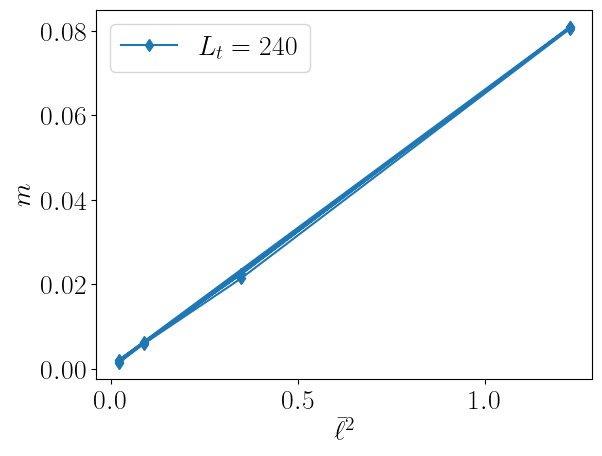

In [144]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
plt.plot( a_s[12:].T[0]**2, np.sqrt(2.0)-masses.T[2][12:], label="$L_t=240$", marker='d' )

plt.legend()

# xxx=np.linspace( 0.0, 1.2, 100 )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.xscale("log")
# plt.yscale("log")

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

plt.xlabel("$\\bar{\\ell}^2$")
plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

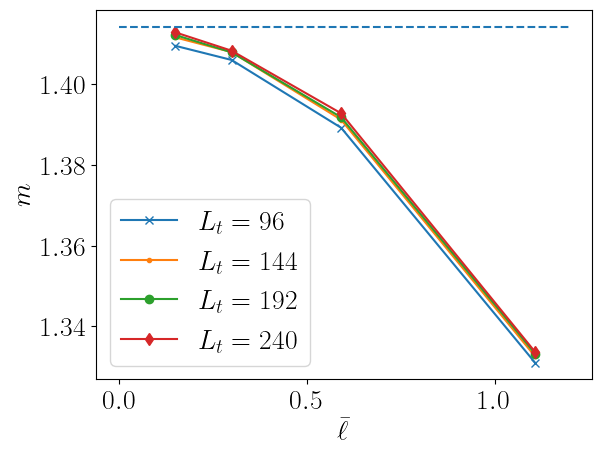

In [103]:
# plt.plot( a_s[:4].T[0], masses.T[2][:4], label="$L_t=96$", marker='x' )
# plt.plot( a_s[4:8].T[0], masses.T[2][4:8], label="$L_t=144$", marker='.' )
# plt.plot( a_s[8:12].T[0], masses.T[2][8:12], label="$L_t=192$", marker='o' )
# plt.plot( a_s[12:].T[0], masses.T[2][12:], label="$L_t=240$", marker='d' )

# plt.legend()

# # xxx=np.linspace( 0.0, 1.2, 100 )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[0][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=96$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[4][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=144$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[7][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=192$", ls='dotted' )
# # plt.plot( xxx, fitter([ xxx, np.full(100, a_s[10][1]) ], opt1[0][0], opt1[0][1], opt1[0][2] ), label="$L_t=240$", ls='dotted' )

# plt.hlines( np.sqrt(2.0), 0.0, 1.2, ls='dashed' )

# plt.xlabel("$\\bar{\\ell}$")
# plt.ylabel("$m$")

# plt.savefig("m_ellbar.pdf", bbox_inches="tight")

In [125]:
a_s[0][1]

0.16666666666666666